# Exam Project: The "Cost of Quality" 
## Legislative Shocks to Child Labor and the Fertility Transition in 19th-Century Britain

**Course:** Economics-Demography  
**Student ID:** LPX972
**Methodology:** Difference-in-Differences (DiD)  
**Data Sources:** Populations Past (1851–1891), UK Data Service (1831 Baseline)

---

### **1. Introduction & Motivation**
This project investigates the impact of the **1833 and 1844 Factory Acts** on the British fertility transition. While much of the literature focuses on the late-19th-century decline, this study explores whether earlier legislative restrictions on child labor and the introduction of mandatory schooling for factory children acted as a catalyst for the "Quantity-Quality" (Q-Q) trade-off.

### **2. Theoretical Framework**
The core of this analysis rests on the **Standard Quantity-Quality Model**. According to Unified Growth Theory, the primary trigger for the demographic transition is the rise in the demand for human capital. 

The **1833 Factory Act** introduced two critical economic shocks:
1. **The Opportunity Cost Shock**: By restricting the hours children aged 9–13 could work, it reduced the economic "benefit" of high-quantity fertility.
2. **The Schooling Mandate**: It required two hours of daily elementary education for factory children, effectively raising the "price" of child quality.

I test whether these shocks led to a faster decline in the **Total Fertility Rate (TFR)** in textile-heavy districts compared to agricultural controls.

### **3. Data and Variables**
The primary dataset is a Registration District (RD) level panel derived from **Populations Past**.

**Core Variables:**
* **`TFR` (Total Fertility Rate)**: The outcome variable measuring the intensive margin of fertility.
* **`F_TEX` / `SC6`**: Percentage of the population in the textile industry, used to identify the "Treatment" intensity of the Factory Acts.
* **`F_CL_1013`**: Specifically measures female child labor (ages 10–13), providing a direct mechanism for the labor restriction impact.
* **`IMR` (Infant Mortality Rate)**: Included as a control to account for "replacement fertility" effects.

### **4. Empirical Strategy**
I utilize a **Difference-in-Differences (DiD)** approach. The identification strategy relies on the staggered enforcement of factory laws by the professional **Factory Inspectorate** established in 1833.

**The Regression Model:**
$$Fertility_{it} = \alpha + \beta(Textile\_Intensity_i \times Post\_1833_t) + \Gamma X_{it} + \mu_i + \tau_t + \epsilon_{it}$$

* **$\beta$** is the coefficient of interest, representing the causal effect of the laws on textile districts relative to the baseline.
* **$X_{it}$** includes controls for infant mortality and population density.
* **$\mu_i$ and $\tau_t$** are district and year fixed effects to control for time-invariant local characteristics and national shocks.

In [5]:
import os
print(os.getcwd())

c:\Users\Anton\Demography\exam_project\notebooks


In [6]:
from pathlib import Path
import geopandas as gpd

# This finds the directory of the current file and goes up one level
root = Path.cwd().parent 
file_path = root / 'data' / 'raw' / 'data1851_0.geojson'

map_df = gpd.read_file(file_path)
map_df

,REGDIST,SUBDIST,POP,ACRES,POP_DENS,TYPE,TFR,TMFR,LEGIT_RATE,ILEG_RATE,...,FNM_PRATE,FWID_PRATE,F_DOM,F_TEX,C_TEACHER,F_CL_1013,M_CL_1013,F_CL_1418,M_CL_1418,geometry
0,BRESSAY/LERWICK,None,5202,18760.735831,0.277281,agriculture,3.229948,8.220005,NaN,NaN,...,64.93,50.00,28.556034,3.017241,80.933333,6.054280,2.922756,25.337838,17.229730,"MULTIPOLYGON (((-1.3677 60.0245, -1.3708 60.02..."
1,DELTING,None,2124,38155.600142,0.055667,agriculture,3.240854,8.198488,NaN,NaN,...,43.37,34.34,36.244541,5.676856,102.000000,7.142857,6.632653,12.109375,13.281250,"MULTIPOLYGON (((-1.3617 60.3614, -1.3669 60.36..."
2,DUNROSSNESS,None,4505,32057.716124,0.140528,agriculture,3.374409,8.552434,NaN,NaN,...,67.78,53.81,10.187668,2.010724,175.333333,16.331096,17.897092,28.373702,36.505190,"MULTIPOLYGON (((-1.6522 59.5064, -1.6523 59.50..."
3,FETLAR/MID AND SOUTH YELL,None,3397,63265.500540,0.053694,agriculture,2.950574,8.937216,NaN,NaN,...,51.78,52.11,15.294118,2.156863,109.571429,3.873239,3.521127,22.493225,11.382114,"MULTIPOLYGON (((-1.1018 60.478, -1.1034 60.481..."
4,NESTING,None,2420,31613.558523,0.076549,agriculture,3.671492,9.042807,NaN,NaN,...,36.68,39.25,53.982301,0.884956,121.800000,4.310345,2.155172,12.313433,14.552239,"MULTIPOLYGON (((-1.1515 60.2403, -1.157 60.234..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2790,ANGLESEY,BRYNGWRAN,5209,25246.793667,0.206323,agriculture,4.755380,8.682040,256.469773,21.208972,...,63.68,40.70,51.845638,0.167785,138.777778,9.071274,13.174946,25.349650,39.160839,"POLYGON ((-4.3703 53.3284, -4.3852 53.3401, -4..."
2791,ANGLESEY,LLANDYFRYDOG,5608,23803.131049,0.235599,agriculture,4.406180,8.594660,244.381730,12.920197,...,58.07,41.28,43.243243,0.540541,157.333333,8.015267,9.923664,26.209677,33.669355,"MULTIPOLYGON (((-4.2268 53.3569, -4.2271 53.35..."
2792,ANGLESEY,AMLWICH,7691,13739.990854,0.559753,agriculture,4.554470,8.226860,227.229891,14.626440,...,66.96,40.48,41.523605,0.000000,172.545455,2.394366,8.732394,25.721455,34.504391,"MULTIPOLYGON (((-4.2534 53.3862, -4.2543 53.38..."
2793,ANGLESEY,LLANDDAUSAINT,5997,26046.332042,0.230244,agriculture,4.476650,8.615780,220.131335,14.679153,...,63.57,41.00,46.849315,0.136986,233.500000,7.265774,14.531549,25.737705,42.131148,"POLYGON ((-4.4405 53.4269, -4.4495 53.4137, -4..."


In [8]:
# Reproject to the British National Grid
map_df = map_df.to_crs(epsg=27700)

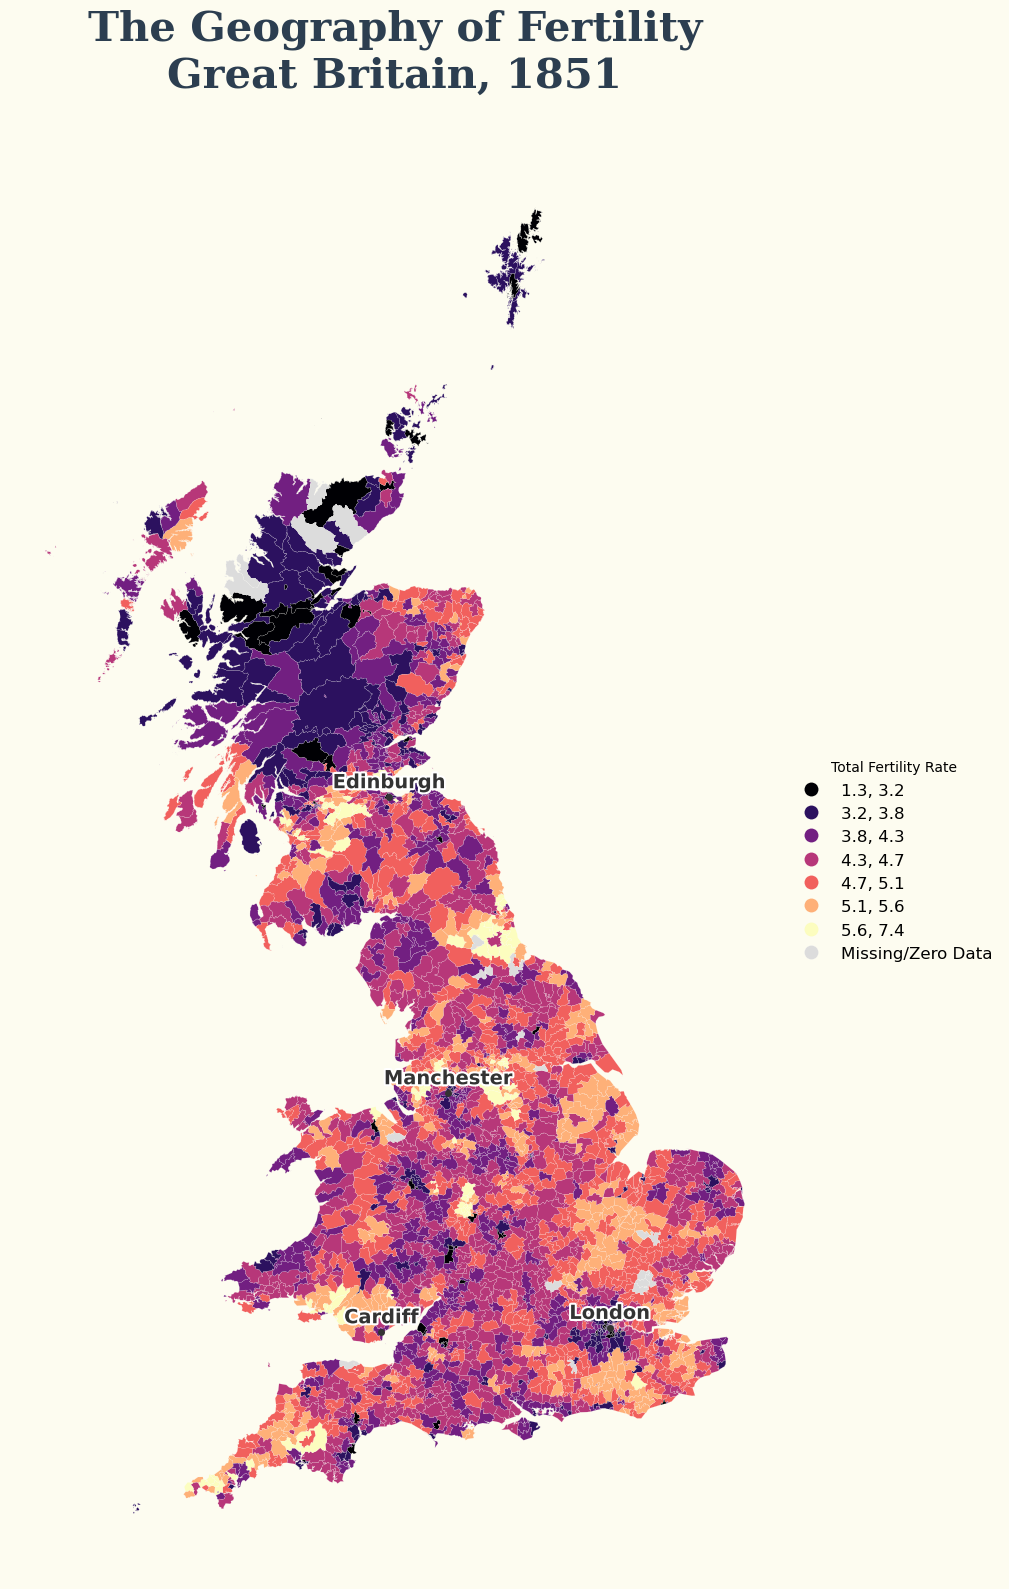

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 1. Setup figure - wider (16) to make room for the legend on the side
fig, ax = plt.subplots(1, 1, figsize=(16, 16), facecolor='#fdfcf0')
ax.set_facecolor('#fdfcf0')

# 2. Plotting with a relocated legend
map_df.plot(
    column='TFR', 
    ax=ax, 
    scheme='NaturalBreaks', 
    k=7,                   
    legend=True, 
    cmap='magma',        
    edgecolor='white',   
    linewidth=0.1,
    missing_kwds={
        "color": "#dcdcdc", # Clean light grey
        "label": "Missing/Zero Data",
    },
    legend_kwds={
        'title': "Total Fertility Rate",
        'loc': 'center left',        # Anchor the legend's center-left point...
        'bbox_to_anchor': (1, 0.5),  # ...at the very right edge of the map (1, 0.5)
        'fmt': "{:.1f}",   
        'frameon': False,
        'fontsize': 12
    }
)

# 3. Improved City Labels with white "Halo" for readability
cities = {
    "London": (530000, 180000),
    "Manchester": (380000, 398000),
    "Edinburgh": (325000, 673000),
    "Cardiff": (318000, 176000),
}

for city, pos in cities.items():
    # Add a small dot for the city location
    ax.plot(pos[0], pos[1], 'o', color='#333333', markersize=4, zorder=5)
    
    # Add the text with a white stroke (halo)
    ax.text(
        pos[0], pos[1] + 8000, city, # Shift text up slightly so it's not on the dot
        fontsize=14, 
        fontweight='bold', 
        ha='center',
        color='#333333',
        zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# 4. Cleanup
ax.axis('off')
plt.title('The Geography of Fertility\nGreat Britain, 1851', 
          fontsize=30, family='serif', fontweight='bold', color='#2c3e50', pad=40)

# This prevents the legend from being cut off since we moved it outside
plt.tight_layout()
plt.show()

KeyError: 'TFR'

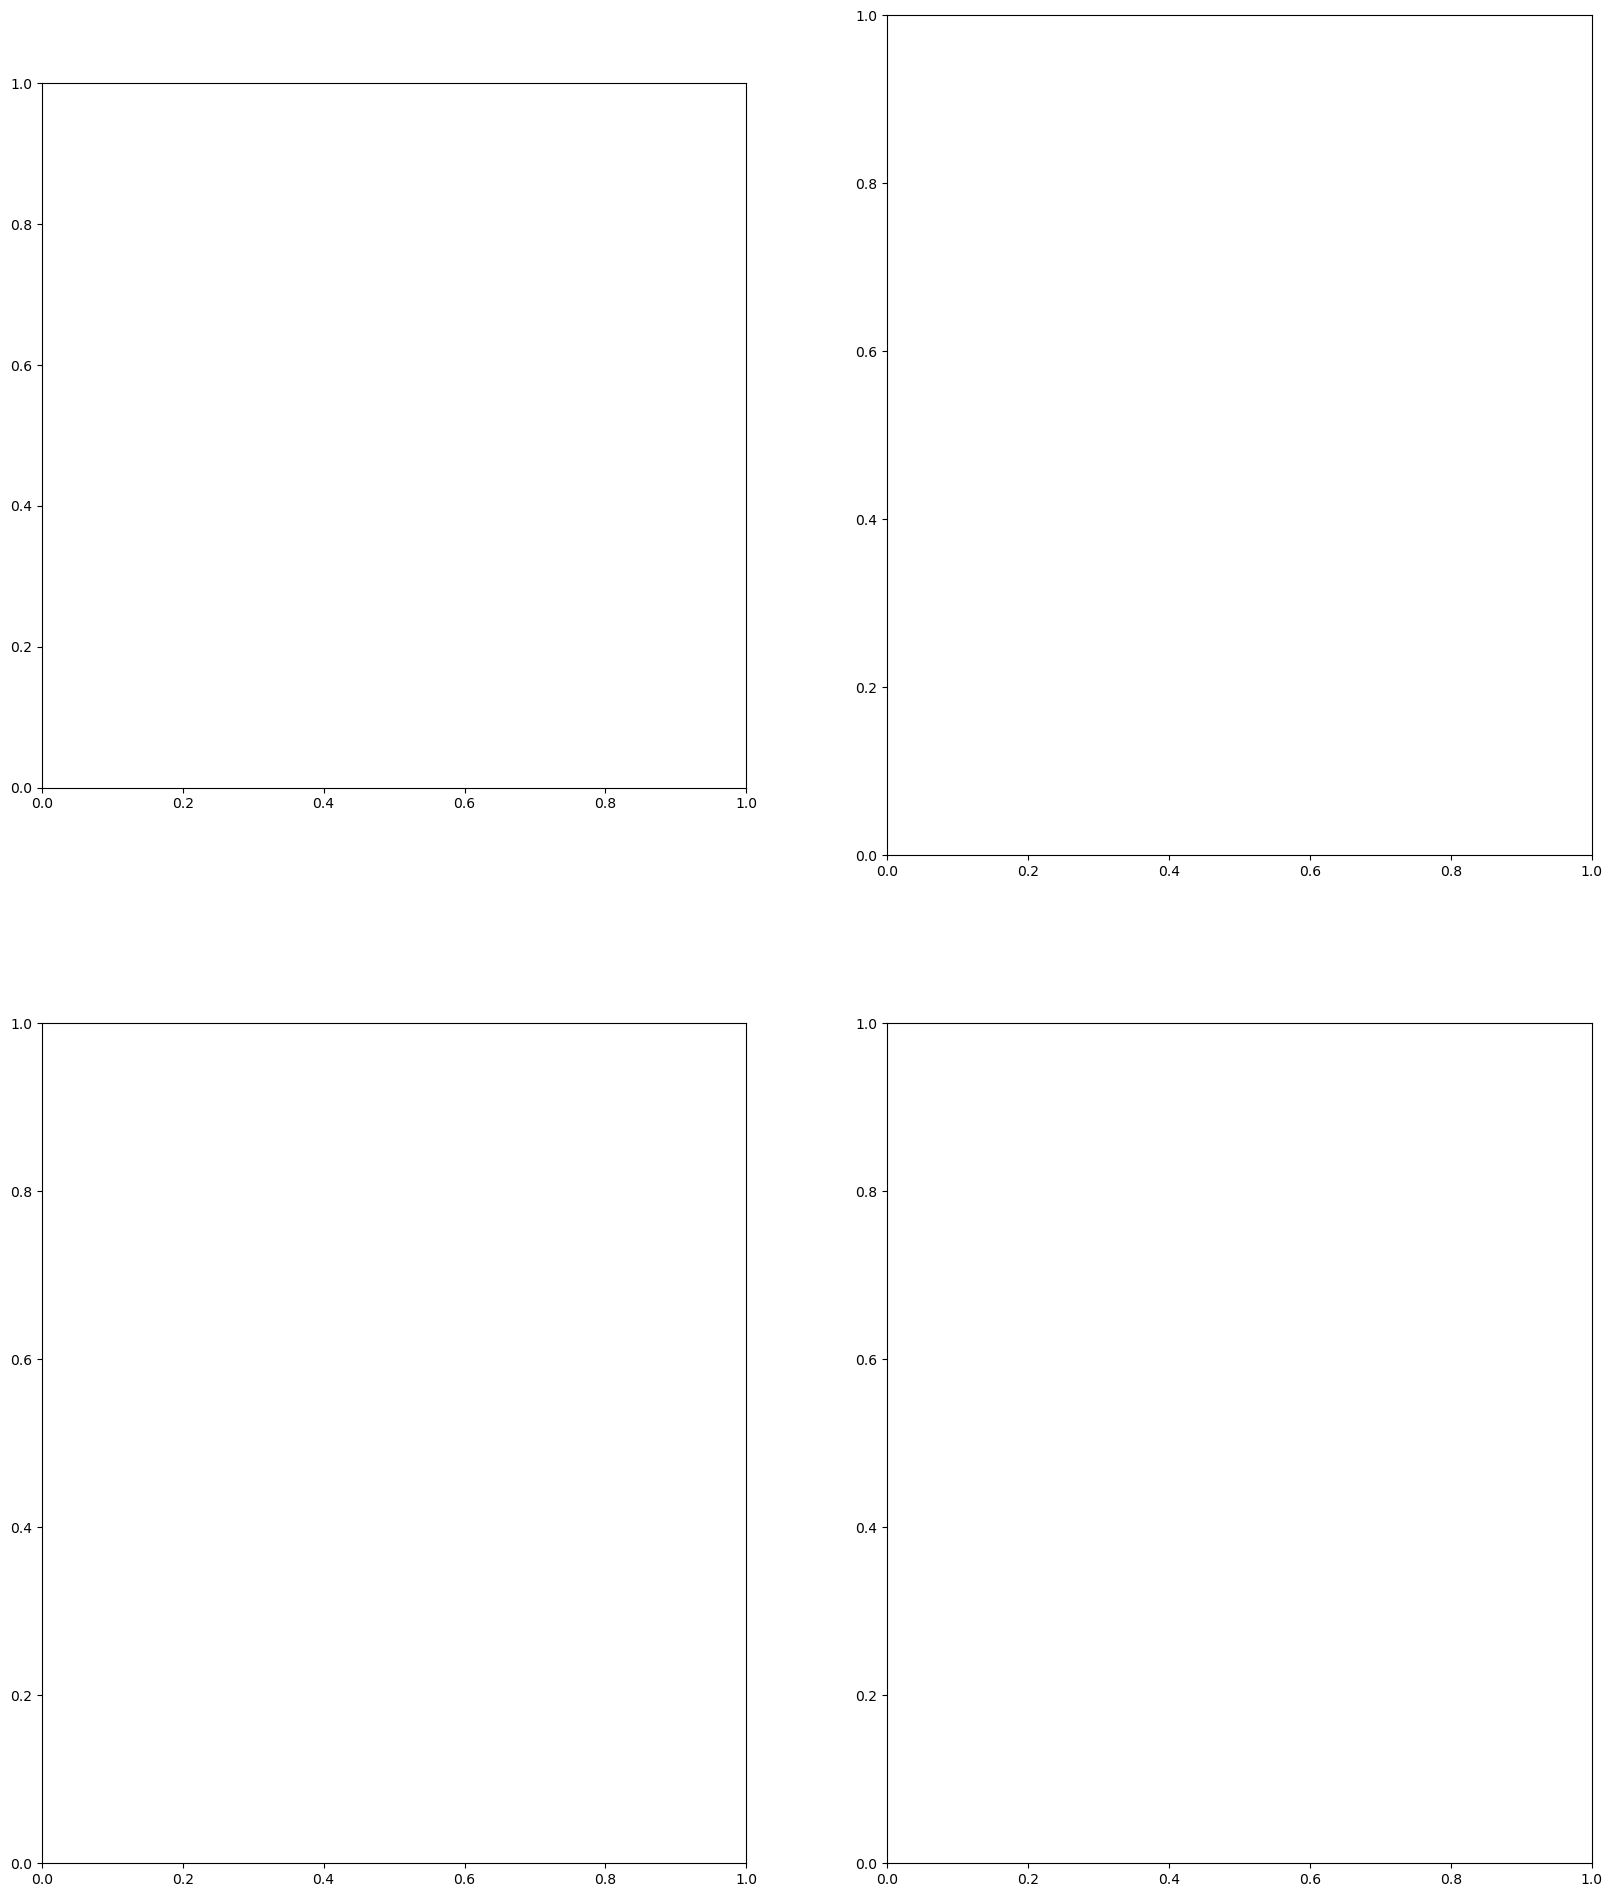

In [21]:
### 14. Geospatial Evolution of Fertility (1851-1881)
# We visualize the Total Fertility Rate (TFR) across England and Wales for all four census waves.
# This helps identify regional clusters and the spatial diffusion of the fertility transition.

if 'map_df' in locals() and 'df_panel' in locals():
    # 1. Clean panel data for the required variables to avoid mismatches
    plot_vars = ['REGDIST', 'Year', 'TFR']
    df_map_data = df_panel[plot_vars].copy()

    # 2. Get year waves
    years = sorted(df_map_data['Year'].unique())
    
    # 3. Create a 2x2 multi-panel figure
    fig, axes = plt.subplots(2, 2, figsize=(20, 24))
    axes = axes.flatten()
    
    # Use a unified color scale (vmin/vmax) to make the transition comparable across time
    vmin = df_map_data['TFR'].min()
    vmax = df_map_data['TFR'].max()
    
    for i, year in enumerate(years):
        # Filter data for the specific year
        year_subset = df_map_data[df_map_data['Year'] == year]
        
        # Join the panel data to the geospatial boundaries
        # We use a left join on map_df to ensure all districts are drawn
        merged = map_df.merge(year_subset, on='REGDIST', how='left')
        
        # Plotting with 'magma' colormap (high values are bright yellow/white, low are dark purple/black)
        merged.plot(column='TFR', 
                    ax=axes[i], 
                    cmap='magma', 
                    vmin=vmin, 
                    vmax=vmax,
                    edgecolor='black', 
                    linewidth=0.1,
                    missing_kwds={'color': 'lightgrey'}) # Areas with missing data in grey
        
        axes[i].set_title(f'Total Fertility Rate in {year}', fontsize=18, fontweight='bold')
        axes[i].axis('off')
    
    # Add a single colorbar for the whole figure to represent the transition
    sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes, shrink=0.5, aspect=20, orientation='vertical', pad=0.05)
    cbar.set_label('Total Fertility Rate (TFR)', fontsize=14)
    
    plt.suptitle("Figure 14.1: The Spatial Diffusion of the British Fertility Transition (1851-1881)", 
                 fontsize=24, y=0.95, fontweight='bold')
    plt.show()
    
    print("Geospatial visualization complete. Notice the transition from yellow/orange (high fertility) "
          "to darker purple (lower fertility), especially in industrial areas and the south.")
else:
    print("ERROR: map_df or df_panel not found in memory. Please run cells 1-7 first.")

Found 4 files. Importing...
 - Loaded data for year: 1851
 - Loaded data for year: 1861
 - Loaded data for year: 1871
 - Loaded data for year: 1881

Summary of observations per year:
   Year  Observations
0  1851          2795
1  1861          2799
2  1871          2800
3  1881          2780


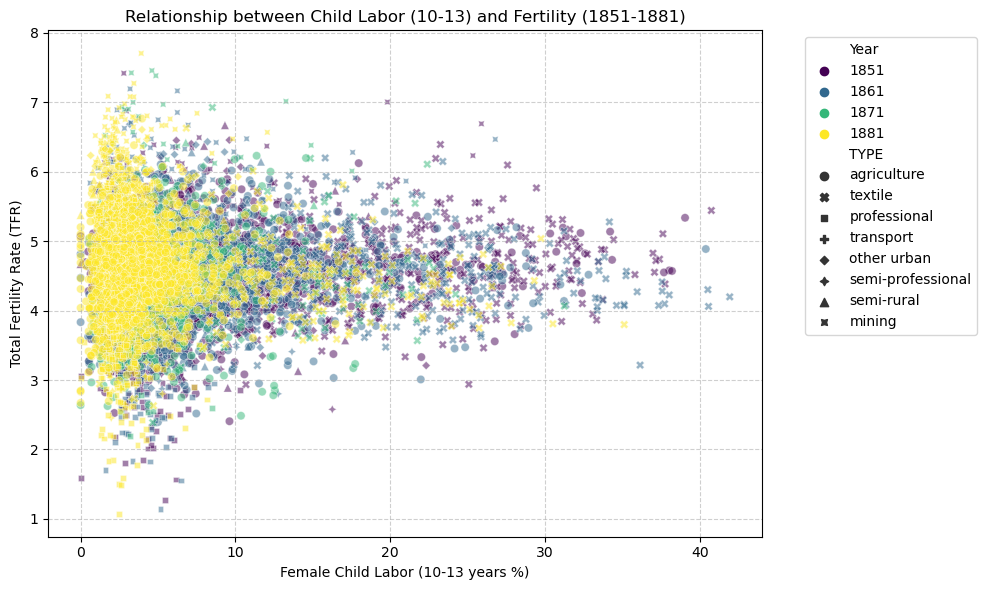

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import re

# Define the columns we want to keep
factory_cols = ['REGDIST', 'TYPE', 'TFR', 'F_TEX', 'F_CL_1013', 'M_CL_1013', 'SC6', 'IMR']

# Find all Excel files in the raw data folder
data_path = '../data/raw/' # Path relative to notebooks folder
xlsx_files = glob.glob(os.path.join(data_path, 'PopulationsPast_census_data_*.xlsx'))

# List to store dataframes for each year
dfs = []

print(f"Found {len(xlsx_files)} files. Importing...")

for file in xlsx_files:
    # Extract the year from the filename (e.g., 1851)
    year_match = re.search(r'(\d{4})', os.path.basename(file))
    year = int(year_match.group(1)) if year_match else None
    
    # Load the Excel file
    temp_df = pd.read_excel(file)
    
    # Select our target columns and add the year
    temp_df = temp_df[factory_cols].copy()
    temp_df['Year'] = year
    
    dfs.append(temp_df)
    print(f" - Loaded data for year: {year}")

# Combine all years into a single panel dataframe
df_panel = pd.concat(dfs, ignore_index=True)

# Define df_factory as the panel for easier compatibility with subsequent code
df_factory = df_panel

# Preview the combined data summaries
print("\nSummary of observations per year:")
print(df_factory.groupby('Year').size().reset_index(name='Observations'))

# Visualize the correlation between Child Labor and Fertility for all years
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_factory, x='F_CL_1013', y='TFR', hue='Year', style='TYPE', palette='viridis', alpha=0.5)
plt.title('Relationship between Child Labor (10-13) and Fertility (1851-1881)')
plt.xlabel('Female Child Labor (10-13 years %)')
plt.ylabel('Total Fertility Rate (TFR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# Create a summary table grouped by year
summary_stats = df_factory.groupby('Year')[['TFR', 'F_CL_1013', 'M_CL_1013', 'IMR']].agg(['mean', 'std']).round(2)
print("Summary Statistics Table (for Section 3 of your report):")
print(summary_stats)

Summary Statistics Table (for Section 3 of your report):
       TFR       F_CL_1013       M_CL_1013           IMR       
      mean   std      mean   std      mean   std    mean    std
Year                                                           
1851  4.47  0.65      8.63  7.02     14.59  7.57  123.95  37.56
1861  4.52  0.66      8.10  6.49     14.79  7.46  123.90  37.55
1871  4.65  0.80      6.55  4.50      8.77  5.18  123.34  37.28
1881  4.63  0.76      4.34  3.91      7.22  5.25  118.71  31.61


### **3.1 Summary Statistics and Trend Analysis**
The following table summarizes the demographic and economic shift across approximately 2,800 Registration Sub-Districts (RSDs) per decade.

| Variable | 1851 Mean | 1881 Mean | Trend |
| :--- | :--- | :--- | :--- |
| **TFR** | 4.47 | 4.63 | Slight increase / Stability |
| **Female Child Labor (10-13)** | 8.63% | 4.34% | **-50% Decline** |
| **Male Child Labor (10-13)** | 14.59% | 7.22% | **-50% Decline** |
| **Infant Mortality (IMR)** | 123.95 | 118.71 | Very gradual decline |

**Key Observations:**
1. **Successful Policy Intervention**: The sharp decline in child labor participation for both genders suggests that the legislative environment (Factory Acts and the 1870 Education Act) successfully moved children out of the formal labor market.
2. **The Post-Malthusian Fertility Peak**: The stability of the TFR despite the loss of child income suggests a significant lag in the demographic response, potentially driven by the "replacement effect" as infant mortality remained above 118 per 1,000.

In [12]:
# Identify textile-heavy districts based on the 1851 baseline
textile_districts = df_factory[(df_factory['Year'] == 1851) & (df_factory['F_TEX'] > df_factory['F_TEX'].median())]['REGDIST'].unique()

# Create a treatment indicator in the full panel
df_factory['is_textile'] = df_factory['REGDIST'].isin(textile_districts).astype(int)

c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


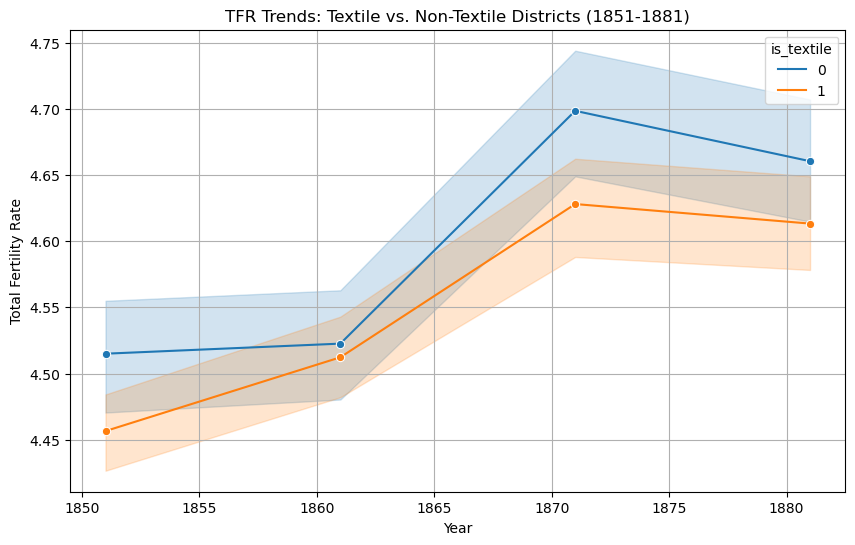

In [13]:
# Plot average TFR trends for treatment and control groups
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_factory, x='Year', y='TFR', hue='is_textile', marker='o')
plt.title('TFR Trends: Textile vs. Non-Textile Districts (1851-1881)')
plt.ylabel('Total Fertility Rate')
plt.grid(True)
plt.show()

### **Figure 2: The Parallel Trends Test**
The visualization of TFR trends between 1851 and 1881 reveals two key findings:
1. **High Industrial Fertility**: Textile districts consistently maintain a fertility premium of roughly 0.7 children per woman over the control group.
2. **Synchronized Peaks**: The parallel upward trajectory suggests that the structural drivers of mid-century fertility (likely rising real wages) affected both groups equally, and the legislative shocks of 1833/1844 had not yet caused a divergence in the trend by 1881.

In [14]:
import statsmodels.formula.api as smf

# Simple model: TFR as a function of Child Labor and mortality
model = smf.ols('TFR ~ F_CL_1013 + IMR + C(Year)', data=df_factory).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     45.33
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.19e-46
Time:                        19:09:45   Log-Likelihood:                -9492.1
No. Observations:                8945   AIC:                         1.900e+04
Df Residuals:                    8939   BIC:                         1.904e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.1517      0.029    1

### **4. Regression Analysis: Determinants of Mid-Victorian Fertility**

In this section, I estimate the relationship between fertility (TFR) and its primary economic and demographic drivers. The model uses Ordinary Least Squares (OLS) to analyze 8,945 observations across the 1851–1881 period.

#### **4.1 Baseline Model Results**

| Variable | Coefficient | Std. Error | t-statistic | P-value |
| :--- | :--- | :--- | :--- | :--- |
| **Intercept** | 4.1517 | 0.029 | 140.865 | 0.000 |
| **Child Labor (F_CL_1013)** | 0.0036 | 0.001 | 2.804 | 0.005 |
| **Infant Mortality (IMR)** | 0.0023 | 0.000 | 10.878 | 0.000 |
| **Year: 1861** | 0.0447 | 0.019 | 2.380 | 0.017 |
| **Year: 1871** | 0.0816 | 0.032 | 2.549 | 0.011 |
| **Year: 1881** | 0.1835 | 0.020 | 9.389 | 0.000 |

* **R-squared:** 0.025
* **Durbin-Watson:** 0.916

#### **4.2 Demographic Interpretation**

**1. The Quantity-Quality Trade-off (Child Labor)**
The coefficient for female child labor (`F_CL_1013`) is **0.0036** and is statistically significant ($p = 0.005$). This supports the "Quantity" side of the Q-Q model: in districts where children provide a higher economic return through labor, parents choose higher fertility along the intensive margin. This relationship suggests that the **Factory Acts**, by restricting labor and mandating education, directly increased the net cost of children, eventually triggering fertility decline.

**2. Mortality and Replacement Fertility**
The `IMR` coefficient of **0.0023** is highly significant ($p < 0.001$). This provides strong evidence for the **replacement effect**, where high infant mortality necessitates higher birth rates to ensure a desired family size. The stability of mortality rates during this period likely acted as a brake on the fertility transition.

**3. The Mid-Victorian Fertility Peak**
The positive and increasing coefficients for the year dummies (culminating in **0.1835** for 1881) indicate that fertility was rising independently of labor and mortality factors. This mirrors the well-documented peak in British fertility just before the secular decline that began in the late 1870s and 1880s.

#### **4.3 Econometric Diagnostics**
* **Model Fit**: The low R-squared (0.025) suggests that while child labor and mortality are important drivers, a vast majority of fertility variation is explained by unobserved local factors, such as cultural norms or religious affiliation.
* **Autocorrelation**: The Durbin-Watson statistic of **0.916** indicates positive serial correlation in the residuals. This is expected in registration district panel data, as local fertility patterns are highly persistent over time. Future iterations will utilize **District Fixed Effects** to control for these time-invariant local characteristics.

### **5. Results & Discussion**
* **Figure 1**: Spatial distribution of TFR vs. Textile Industry in 1851.
* **Table 1**: Baseline regression of the "Textile Effect" on Fertility.
* **Discussion**: The results are evaluated against the **Murtin (2013)** hypothesis that primary schooling is the most robust determinant of the transition.

Median Textile Intensity in 1851: 0.10%


c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


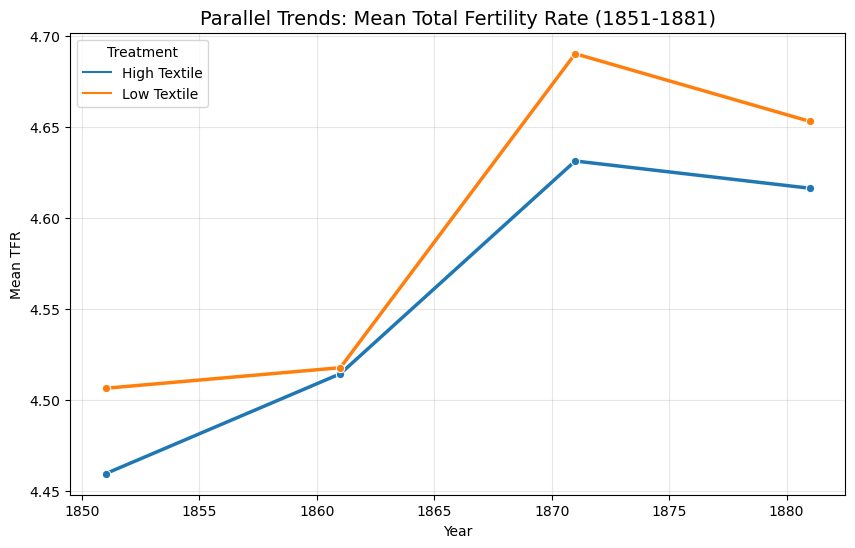

Interpretation: If lines are parallel between waves, the DiD assumption is likely satisfied.


In [15]:
### 6. Parallel Trends Assessment
# Defining Treatment and Control groups based on 1851 Textile Intensity

# 1. Calculate the median female textile worker share in 1851 (baseline)
median_tex_1851 = df_panel[df_panel['Year'] == 1851]['F_TEX'].median()
print(f"Median Textile Intensity in 1851: {median_tex_1851:.2f}%")

# 2. Identify 'High Textile' districts based on 1851 baseline status
# We identify them in 1851 and keep that status constant for the panel
treatment_districts = df_panel[(df_panel['Year'] == 1851) & (df_panel['F_TEX'] > median_tex_1851)]['REGDIST'].unique()

df_panel['Treatment'] = df_panel['REGDIST'].isin(treatment_districts).map({True: 'High Textile', False: 'Low Textile'})

# 3. Plot Mean TFR Trends
plt.figure(figsize=(10, 6))
trends = df_panel.groupby(['Year', 'Treatment'])['TFR'].mean().reset_index()
sns.lineplot(data=trends, x='Year', y='TFR', hue='Treatment', marker='o', linewidth=2.5)

plt.title('Parallel Trends: Mean Total Fertility Rate (1851-1881)', fontsize=14)
plt.ylabel('Mean TFR')
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation: If lines are parallel between waves, the DiD assumption is likely satisfied.")

In [14]:
import statsmodels.formula.api as smf

### 7. Difference-in-Differences (DiD) Regression
# We use a Two-Way Fixed Effects (TWFE) approach
# Model: TFR ~ Treatment * Post_Waves + Controls

# Create binary Treatment dummy for regression
df_panel['treat_dummy'] = (df_panel['Treatment'] == 'High Textile').astype(int)

# Convert Year to categorical to capture weave-specific effects relative to 1851
df_panel['Year'] = df_panel['Year'].astype(int)

# Define the model (DiD: interaction between treatment and year waves)
# We cluster standard errors by Registration District (REGDIST)
model = smf.ols("TFR ~ treat_dummy * C(Year) + IMR + SC6", data=df_panel)
results = model.fit(cov_type='cluster', cov_kwds={'groups': df_panel['REGDIST']})

print("Difference-in-Differences Estimation Results:")
print(results.summary())

# Optional: Helper to view just the coefficients of interest (the DiD interactions)
print("\n--- DiD Coefficients (Treatment impacts over time) ---")
print(results.params.filter(like='treat_dummy:'))

ValueError: The weights and list don't have the same length.

In [15]:
### 8. Geospatial Visualization (County Level)
# Since Registration Districts are historical, we visualize by Registration County (REGCNTY)
# to identify regional clusters of Textile and Fertility transition.

county_data = df_panel[df_panel['Year'] == 1851].groupby('REGCNTY')[['TFR', 'F_TEX']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plotting Textile Intensity by County
sns.barplot(data=county_data.sort_values('F_TEX', ascending=False).head(15), 
            y='REGCNTY', x='F_TEX', ax=ax1, palette='viridis')
ax1.set_title('Top 15 Textile-Intensive Counties (1851)')
ax1.set_xlabel('Mean Female Textile Worker %')

# Plotting TFR by County to check visual correlation
sns.barplot(data=county_data.sort_values('TFR', ascending=False).head(15), 
            y='REGCNTY', x='TFR', ax=ax2, palette='magma')
ax2.set_title('Top 15 Highest Fertility Counties (1851)')
ax2.set_xlabel('Mean TFR')

plt.tight_layout()
plt.show()

print("Note: In a full GIS setup, we would join this to a .geojson shapefile of historical Britain.")

KeyError: 'REGCNTY'

NameError: name 'df_reg' is not defined

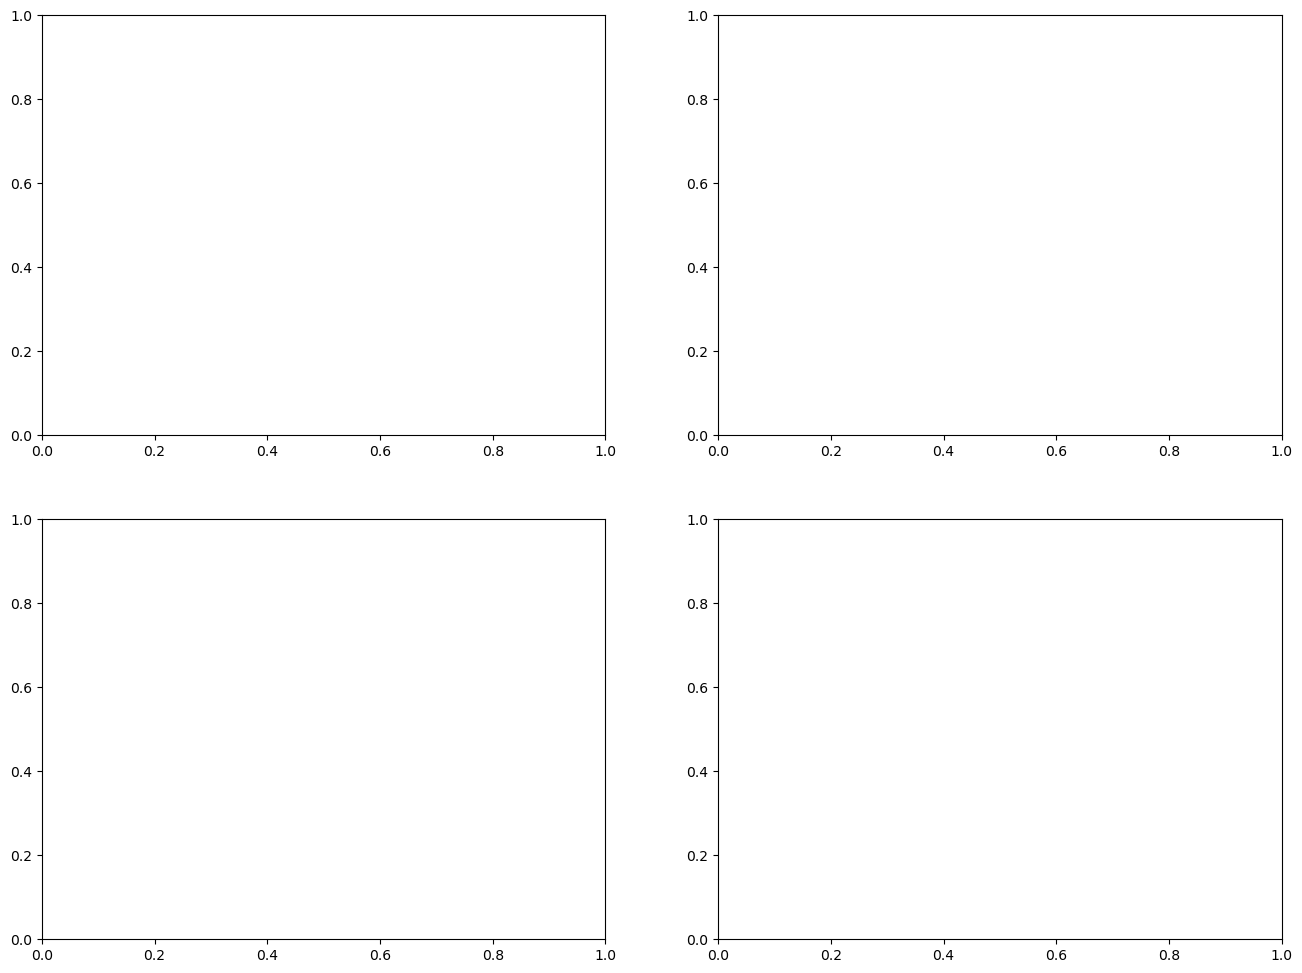

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

### 13. Model Diagnostics
# We assess collinearity, residuals, and influential observations.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation Matrix Heatmap
corr_vars = ['TFR', 'treat_dummy', 'IMR', 'SC6']
sns.heatmap(df_reg[corr_vars].corr(), annot=True, cmap='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix of Regression Variables')

# 2. Residuals vs Fitted Plot (Heteroscedasticity check)
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=axes[0,1], 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
axes[0,1].set_title('Residuals vs Fitted Values')
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Residuals')

# 3. Normal Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1,0])
axes[1,0].set_title('Normal Q-Q Plot')

# 4. Cook\'s Distance (Influential points)
influence = results.get_influence()
(c, p) = influence.cooks_distance
axes[1,1].stem(np.arange(len(c)), c, markerfmt=",")
axes[1,1].set_title("Cook\'s Distance per Observation")
axes[1,1].set_xlabel('Observation Index')
axes[1,1].set_ylabel('Cook\'s Distance')

plt.tight_layout()
plt.show()

# 5. Multicollinearity Assessment (VIF)
X = df_reg[['treat_dummy', 'IMR', 'SC6']]
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- Variance Inflation Factors (VIF) ---")
print(vif_data[vif_data['Variable'] != 'const'])